<a href="https://colab.research.google.com/github/faizankhan-ml/covid19-data-analysis./blob/main/covid_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ILLUSTRATIVE SAMPLE DATA — not verified historical statistics
Input rows: 6
Valid rows: 6


,country,date,cases,deaths
0,Germany,2021-01-01,1800000,35000
1,Germany,2021-06-01,3700000,89000
2,Germany,2021-12-01,6000000,100000
3,Pakistan,2021-01-01,480000,10000
4,Pakistan,2021-06-01,940000,22000
5,Pakistan,2021-12-01,1300000,28000


,max_cases,max_deaths,observations
country,,,
Germany,6000000,100000,3
Pakistan,1300000,28000,3


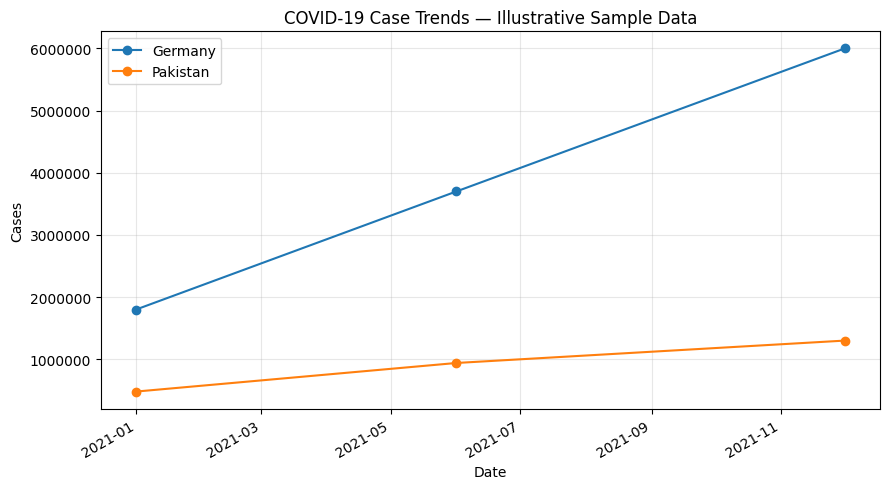

Saved files:
cleaned_data.csv
sample_data.csv
summary.csv
summary.txt
trend.png


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Illustrative sample values, not verified historical statistics.
data = {
    "country": ["Germany"] * 3 + ["Pakistan"] * 3,
    "date": [
        "2021-01-01", "2021-06-01", "2021-12-01",
        "2021-01-01", "2021-06-01", "2021-12-01"
    ],
    "cases": [1800000, 3700000, 6000000, 480000, 940000, 1300000],
    "deaths": [35000, 89000, 100000, 10000, 22000, 28000]
}

def clean_data(df):
    df = df.copy()
    df.columns = df.columns.str.strip().str.lower()

    required = {"country", "date", "cases", "deaths"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns: {sorted(missing)}")

    df["country"] = df["country"].astype("string").str.strip()
    df["country"] = df["country"].replace("", pd.NA)
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    for column in ["cases", "deaths"]:
        df[column] = pd.to_numeric(df[column], errors="coerce")

    df = df.dropna(subset=["country", "date", "cases", "deaths"])
    df = df[
        (df["cases"] >= 0) &
        (df["deaths"] >= 0) &
        (df["deaths"] <= df["cases"])
    ]

    df = df.drop_duplicates()
    return df.sort_values(["country", "date"]).reset_index(drop=True)


output_dir = Path("covid_output")
output_dir.mkdir(exist_ok=True)

# Save and reload CSV to demonstrate the data-loading workflow.
pd.DataFrame(data).to_csv(output_dir / "sample_data.csv", index=False)
raw_data = pd.read_csv(output_dir / "sample_data.csv")
cleaned_data = clean_data(raw_data)

if cleaned_data.empty:
    raise ValueError("No valid rows remain after cleaning.")

summary = cleaned_data.groupby("country").agg(
    max_cases=("cases", "max"),
    max_deaths=("deaths", "max"),
    observations=("date", "count")
)

print("ILLUSTRATIVE SAMPLE DATA — not verified historical statistics")
print(f"Input rows: {len(raw_data)}")
print(f"Valid rows: {len(cleaned_data)}")

display(cleaned_data)
display(summary)

fig, ax = plt.subplots(figsize=(9, 5))

for country, rows in cleaned_data.groupby("country"):
    ax.plot(rows["date"], rows["cases"], marker="o", label=country)

ax.set_title("COVID-19 Case Trends — Illustrative Sample Data")
ax.set_xlabel("Date")
ax.set_ylabel("Cases")
ax.ticklabel_format(axis="y", style="plain")
ax.legend()
ax.grid(alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()

fig.savefig(output_dir / "trend.png", dpi=150)
plt.show()

cleaned_data.to_csv(output_dir / "cleaned_data.csv", index=False)
summary.to_csv(output_dir / "summary.csv")

(output_dir / "summary.txt").write_text(
    "Illustrative sample data; not verified historical statistics.\n\n"
    + summary.to_string(),
    encoding="utf-8"
)

print("Saved files:")
for file in sorted(output_dir.iterdir()):
    print(file.name)

In [2]:
test_data = pd.DataFrame({
    "country": ["Germany", "Pakistan", "Germany", "Pakistan", "Germany"],
    "date": ["2021-01-01", "wrong-date", "2021-02-01",
             "2021-03-01", "2021-01-01"],
    "cases": [100, 200, -50, 100, 100],
    "deaths": [5, 10, 2, 150, 5]
})

test_result = clean_data(test_data)

display(test_result)

assert len(test_result) == 1
assert test_result.iloc[0]["cases"] == 100
assert test_result.iloc[0]["deaths"] == 5

print("PASS: Invalid rows and duplicate removed.")


,country,date,cases,deaths
0,Germany,2021-01-01,100,5


PASS: Invalid rows and duplicate removed.


In [3]:
print(test_result.to_string(index=False))


country       date  cases  deaths
Germany 2021-01-01    100       5
